Loaded rows: 637


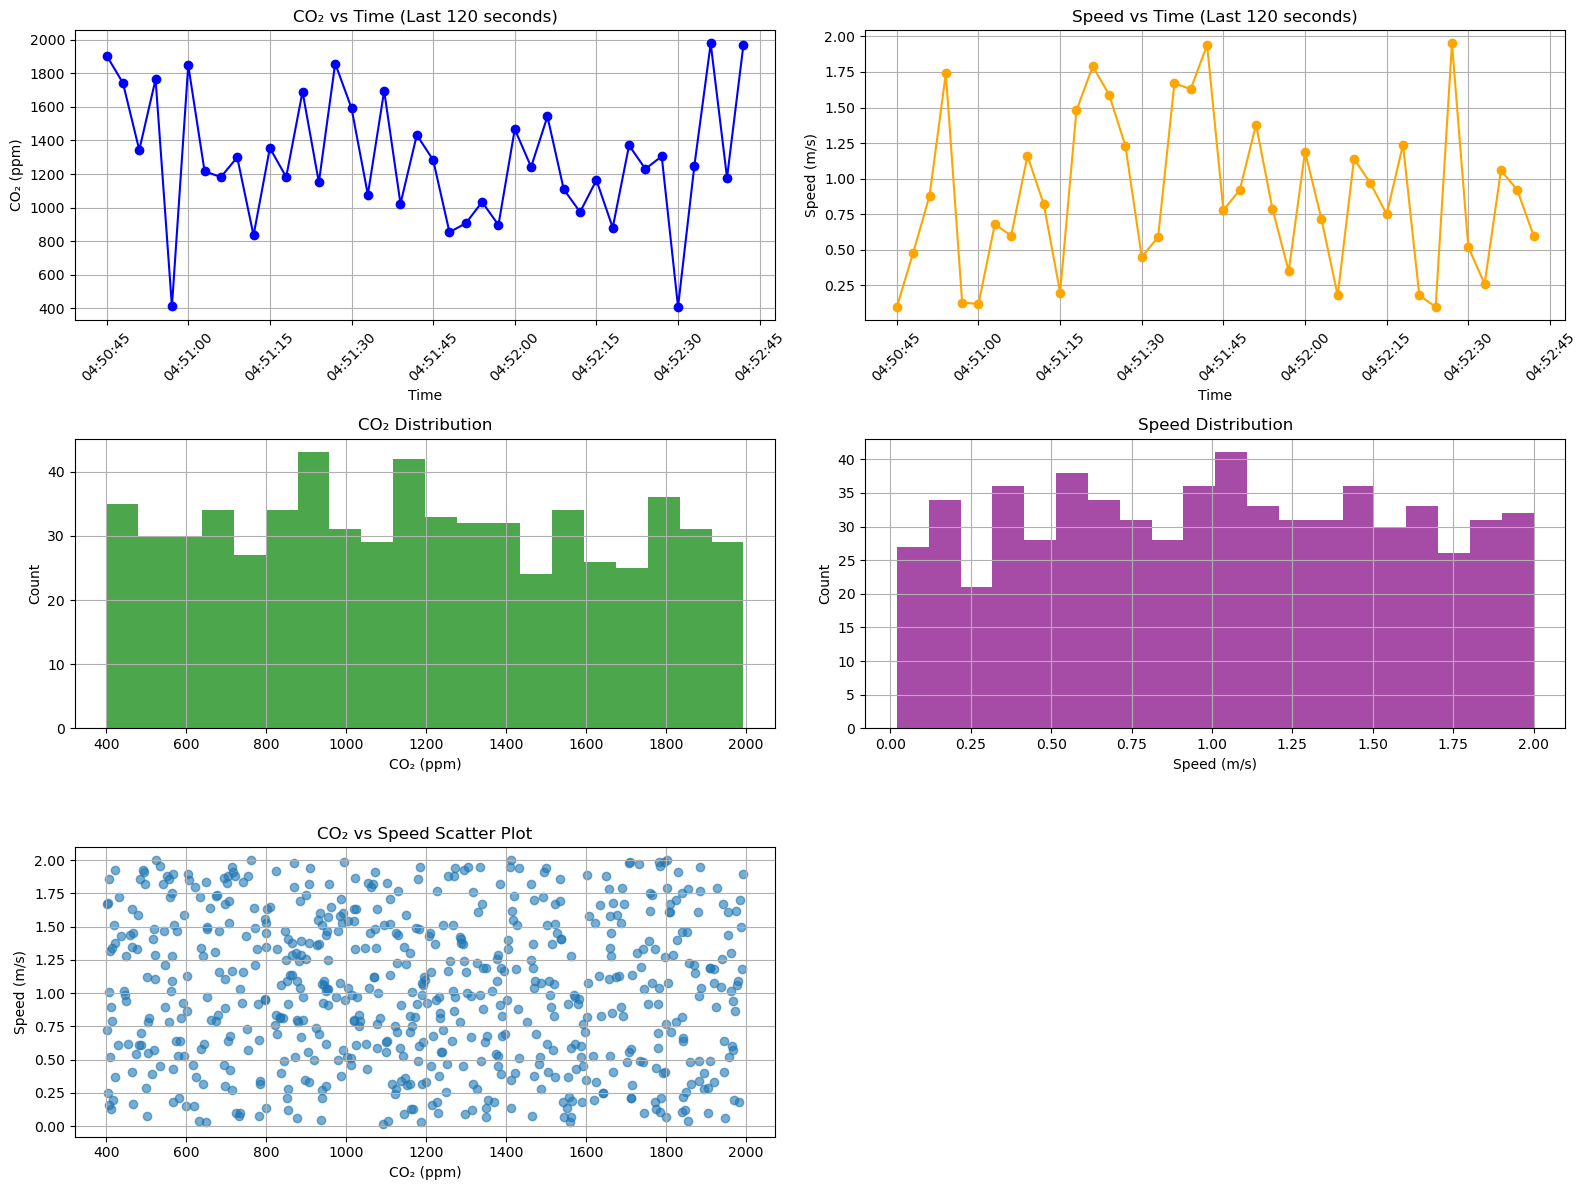

KeyboardInterrupt: 

In [1]:
import boto3
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time
from datetime import datetime, timedelta

# DynamoDB table
dynamodb = boto3.resource('dynamodb')
table = dynamodb.Table('smartkcardata')

def load_data():
    """Load all SmartCar data from DynamoDB"""
    response = table.scan()
    items = response["Items"]

    # If multiple pages
    while "LastEvaluatedKey" in response:
        response = table.scan(ExclusiveStartKey=response["LastEvaluatedKey"])
        items.extend(response["Items"])

    df = pd.DataFrame(items)

    # Convert types
    df["timestamp"] = df["timestamp"].astype(int)
    df["co2"] = df["co2"].astype(float)
    df["speed"] = df["speed"].astype(float)
    df["datetime"] = pd.to_datetime(df["timestamp"], unit="s")

    # Sort by time
    df = df.sort_values("timestamp")

    return df


# =========================================================
# Real-Time Dashboard Loop (3 sec refresh)
# =========================================================
ROLLING_WINDOW = 120   # seconds

while True:
    clear_output(wait=True)

    df = load_data()

    print("Loaded rows:", len(df))

    # Filter last 120 seconds of data
    now = datetime.utcnow()
    cutoff = now - timedelta(seconds=ROLLING_WINDOW)

    df_recent = df[df["datetime"] > cutoff]

    # Prepare figure with 5 subplots
    fig, axs = plt.subplots(3, 2, figsize=(16, 12))
    axs = axs.flatten()

    # ------------------------------------------------
    # Chart 1: CO2 vs Time (last 120 seconds)
    # ------------------------------------------------
    axs[0].plot(df_recent["datetime"], df_recent["co2"],
                marker="o", color="blue")
    axs[0].set_title(f"CO₂ vs Time (Last {ROLLING_WINDOW} seconds)")
    axs[0].set_xlabel("Time")
    axs[0].set_ylabel("CO₂ (ppm)")
    axs[0].tick_params(axis='x', rotation=45)
    axs[0].grid(True)

    # ------------------------------------------------
    # Chart 2: Speed vs Time (last 120 seconds)
    # ------------------------------------------------
    axs[1].plot(df_recent["datetime"], df_recent["speed"],
                marker="o", color="orange")
    axs[1].set_title(f"Speed vs Time (Last {ROLLING_WINDOW} seconds)")
    axs[1].set_xlabel("Time")
    axs[1].set_ylabel("Speed (m/s)")
    axs[1].tick_params(axis='x', rotation=45)
    axs[1].grid(True)

    # ------------------------------------------------
    # Chart 3: CO2 Histogram (all data)
    # ------------------------------------------------
    axs[2].hist(df["co2"], bins=20, color="green", alpha=0.7)
    axs[2].set_title("CO₂ Distribution")
    axs[2].set_xlabel("CO₂ (ppm)")
    axs[2].set_ylabel("Count")
    axs[2].grid(True)

    # ------------------------------------------------
    # Chart 4: Speed Histogram (all data)
    # ------------------------------------------------
    axs[3].hist(df["speed"], bins=20, color="purple", alpha=0.7)
    axs[3].set_title("Speed Distribution")
    axs[3].set_xlabel("Speed (m/s)")
    axs[3].set_ylabel("Count")
    axs[3].grid(True)

    # ------------------------------------------------
    # Chart 5: CO2 vs Speed Scatter (all data)
    # ------------------------------------------------
    axs[4].scatter(df["co2"], df["speed"], alpha=0.6)
    axs[4].set_title("CO₂ vs Speed Scatter Plot")
    axs[4].set_xlabel("CO₂ (ppm)")
    axs[4].set_ylabel("Speed (m/s)")
    axs[4].grid(True)

    # Hide empty 6th subplot
    axs[5].axis("off")

    plt.tight_layout()
    plt.show()

    time.sleep(10)
